In [26]:
import pandas as pd
import numpy as np
import joblib

In [27]:
# ==============================
# LOAD MODEL & FEATURES
# ==============================

model = joblib.load('../Model/xgboost_model.pkl')
features = joblib.load('../Model/feature_columns.pkl')

df = pd.read_csv('../Data/uber_taxi_demand_5years.csv')

df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime')

print("Model loaded!")
print("Features:", len(features))
print("Last date:", df['datetime'].max())

Model loaded!
Features: 22
Last date: 2025-12-31 23:00:00


In [28]:
zone = "Airport"

zone_df = (
    df[df['zone'] == zone]
    .sort_values('datetime')
    .copy()
)

zone_df = zone_df.set_index('datetime')

print("Zone:", zone)
print("Rows:", len(zone_df))
print("Last timestamp:", zone_df.index[-1])
print("Last pickup:", zone_df['pickup_count'].iloc[-1])

Zone: Airport
Rows: 43824
Last timestamp: 2025-12-31 23:00:00
Last pickup: 152


In [ ]:
# ============================================
# 24-HOUR RECURSIVE FORECAST
# ============================================

history = zone_df['pickup_count'].tolist()
last_time = zone_df.index[-1]

# Future timestamps
future_dates = pd.date_range(
    start=last_time + pd.Timedelta(hours=1),
    periods=24,
    freq='h'
)

predictions = []

future_temperature = -3.0
future_precipitation = 0.0
future_is_raining = 0
future_is_holiday = 1

for future_date in future_dates:
    lag_1 = history[-1]
    lag_2 = history[-2]
    lag_3 = history[-3]
    lag_24 = history[-24]
    lag_168 = history[-168]

    rolling_mean_24 = np.mean(history[-24:])
    rolling_mean_168 = np.mean(history[-168:])

    hour = future_date.hour
    day_of_week = future_date.dayofweek
    month = future_date.month

    hour_sin = np.sin(2 * np.pi * hour / 24)
    hour_cos = np.cos(2 * np.pi * hour / 24)

    is_weekend = int(day_of_week >= 5)

    month_sin = np.sin(2 * np.pi * month / 12)
    month_cos = np.cos(2 * np.pi * month / 12)

    time_index = (
        (future_date - df['datetime'].min()).total_seconds()
        / 3600
    )

    zone_Downtown = int(zone == "Downtown")
    zone_Midtown = int(zone == "Midtown")
    zone_Suburb = int(zone == "Suburb")
    zone_Uptown = int(zone == "Uptown")

    # Airport = 0,0,0,0
    # because Airport was the dropped baseline category

    input_data = pd.DataFrame([{
        'time_index': time_index,

        'lag_1': lag_1,
        'lag_2': lag_2,
        'lag_3': lag_3,
        'lag_24': lag_24,
        'lag_168': lag_168,

        'rolling_mean_24': rolling_mean_24,
        'rolling_mean_168': rolling_mean_168,

        'hour_sin': hour_sin,
        'hour_cos': hour_cos,

        'day_of_week': day_of_week,
        'is_weekend': is_weekend,

        'month_sin': month_sin,
        'month_cos': month_cos,

        'temperature': future_temperature,
        'precipitation': future_precipitation,
        'is_raining': future_is_raining,
        'is_holiday': future_is_holiday,

        'zone_Downtown': zone_Downtown,
        'zone_Midtown': zone_Midtown,
        'zone_Suburb': zone_Suburb,
        'zone_Uptown': zone_Uptown
    }])

    input_data = input_data[features]

    prediction = model.predict(input_data)[0]
    prediction = max(0, prediction)
    predictions.append(prediction)

    history.append(prediction)


forecast = pd.DataFrame({
    'datetime': future_dates,
    'zone': zone,
    'predicted_pickups': np.round(predictions, 0)
})

print(forecast)

              datetime     zone  predicted_pickups
0  2026-01-01 00:00:00  Airport               67.0
1  2026-01-01 01:00:00  Airport               44.0
2  2026-01-01 02:00:00  Airport               50.0
3  2026-01-01 03:00:00  Airport               49.0
4  2026-01-01 04:00:00  Airport               42.0
5  2026-01-01 05:00:00  Airport               57.0
6  2026-01-01 06:00:00  Airport               70.0
7  2026-01-01 07:00:00  Airport               74.0
8  2026-01-01 08:00:00  Airport               88.0
9  2026-01-01 09:00:00  Airport               69.0
10 2026-01-01 10:00:00  Airport               48.0
11 2026-01-01 11:00:00  Airport               42.0
12 2026-01-01 12:00:00  Airport               49.0
13 2026-01-01 13:00:00  Airport               39.0
14 2026-01-01 14:00:00  Airport               46.0
15 2026-01-01 15:00:00  Airport               61.0
16 2026-01-01 16:00:00  Airport               74.0
17 2026-01-01 17:00:00  Airport               80.0
18 2026-01-01 18:00:00  Airport

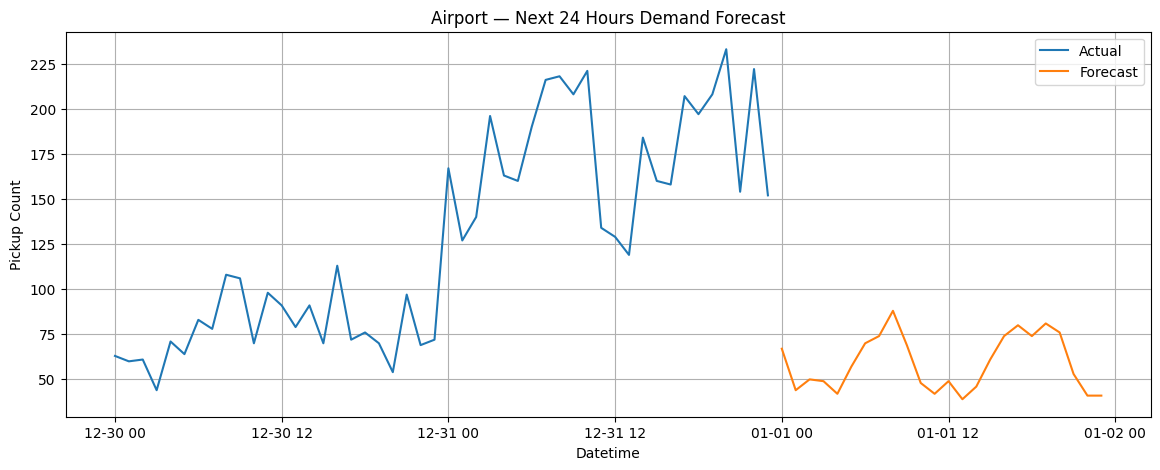

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    zone_df.index[-48:],
    zone_df['pickup_count'].iloc[-48:],
    label='Actual'
)

plt.plot(
    forecast['datetime'],
    forecast['predicted_pickups'],
    label='Forecast'
)

plt.title(f'{zone} — Next 24 Hours Demand Forecast')
plt.xlabel('Datetime')
plt.ylabel('Pickup Count')
plt.legend()
plt.grid(True)

plt.show()

In [31]:
comparison = forecast[['datetime', 'predicted_pickups']].copy()
comparison['datetime'] = pd.to_datetime(comparison['datetime'])
comparison['last_year_datetime'] = comparison['datetime'] - pd.DateOffset(years=1)

last_year = zone_df[['pickup_count']].copy()

comparison = comparison.merge(last_year,left_on='last_year_datetime',right_index=True,how='left')
comparison.rename(columns={'pickup_count': '2025_actual'},inplace=True)

comparison['difference'] = (comparison['predicted_pickups'] - comparison['2025_actual'])

comparison['change_%'] = (
    comparison['difference'] / comparison['2025_actual'] * 100
)

comparison = comparison[
    [
        'datetime',
        '2025_actual',
        'predicted_pickups',
        'difference',
        'change_%'
    ]
]

comparison['predicted_pickups'] = comparison['predicted_pickups'].round(0)
comparison['difference'] = comparison['difference'].round(0)
comparison['change_%'] = comparison['change_%'].round(2)
comparison

,datetime,2025_actual,predicted_pickups,difference,change_%
0,2026-01-01 00:00:00,60,67.0,7.0,11.67
1,2026-01-01 01:00:00,59,44.0,-15.0,-25.42
2,2026-01-01 02:00:00,71,50.0,-21.0,-29.58
3,2026-01-01 03:00:00,85,49.0,-36.0,-42.35
4,2026-01-01 04:00:00,83,42.0,-41.0,-49.40
5,2026-01-01 05:00:00,68,57.0,-11.0,-16.18
6,2026-01-01 06:00:00,82,70.0,-12.0,-14.63
7,2026-01-01 07:00:00,69,74.0,5.0,7.25
8,2026-01-01 08:00:00,69,88.0,19.0,27.54
9,2026-01-01 09:00:00,91,69.0,-22.0,-24.18
